In [1]:
from transformers import DistilBertTokenizerFast, DistilBertModel
import torch
import numpy as np
import sys
from pathlib import Path
import os
import json, re


d:\conda_envs\mdm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 🔧 Load DistilBERT (Tokenizer + Model)
This cell loads the DistilBERT tokenizer and model from HuggingFace.
We use DistilBERT to convert each sentence into a semantic embedding vector (768 dimensions).
These embeddings will later be used for:
- Text-to-text cosine similarity  
- Distance matrices  
- Clustering  
- PCA / UMAP visualizations  

We also detect whether CUDA is available and load the model onto the correct device.


In [2]:

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
bert_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(device)



d:\conda_envs\mdm\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:


def get_repo_root():
    # --- CASE 1: Running inside a notebook ---
    if 'ipykernel' in sys.modules:
        # notebook file is usually inside <root>/scripts/... or <root>/analysis/...
        # so take the notebook cwd and go UP until we find the repo
        cwd = Path().resolve()
        # We assume the notebook is in <root>/scripts or <root>/analysis>
        # → repo root = parent folder
        return cwd.parents[0]

    # --- CASE 2: Running as a .py file ---
    return Path(__file__).resolve().parents[1]

REPO_ROOT = get_repo_root()
print("Detected REPO_ROOT =", REPO_ROOT)
INFERENCE = REPO_ROOT / "save" / "test_custom500_concat_11_4" / "infer_trainset"  
ANNOTATIONS = REPO_ROOT / "GigaHands_Data" / "annotations_v2.jsonl"
print(ANNOTATIONS)
print(INFERENCE)


Detected REPO_ROOT = D:\repos\refactored_MDM
D:\repos\refactored_MDM\GigaHands_Data\annotations_v2.jsonl
D:\repos\refactored_MDM\save\test_custom500_concat_11_4\infer_trainset


# 📘 Text Similarity Helper Functions
This cell defines simple utilities for comparing two sentences using:
- basic token overlap (F1)
- BERT embeddings (cosine similarity)

These functions will be used later to measure how similar different text instructions are.


In [4]:
def tokenize(text):
    import re
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return text.strip().split()

def f1_token_overlap(text1, text2):
    t1 = set(tokenize(text1))
    t2 = set(tokenize(text2))
    if len(t1) == 0 or len(t2) == 0:
        return 0.0
    tp = len(t1 & t2)
    fp = len(t1 - t2)
    fn = len(t2 - t1)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return 2 * precision * recall / (precision + recall + 1e-8)

def cosine_similarity(a, b):
    a = a / (np.linalg.norm(a) + 1e-8)
    b = b / (np.linalg.norm(b) + 1e-8)
    return float(np.dot(a, b))

def bert_embedding(bert_model, tokenizer, text, device):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=40)
    tokens = {k: v.to(device) for k, v in tokens.items()}
    with torch.no_grad():
        out = bert_model(**tokens).last_hidden_state
    return out.mean(dim=1).squeeze(0).cpu().numpy()

def compare_texts(t1, t2, bert_model, tokenizer, device):
    scores = {}
    scores["f1"] = f1_token_overlap(t1, t2)

    e1 = bert_embedding(bert_model, tokenizer, t1, device)
    e2 = bert_embedding(bert_model, tokenizer, t2, device)
    scores["bert_cosine"] = cosine_similarity(e1, e2)

    return scores


# 📊 Compare Two Example Sentences
This cell computes the similarity between two sample sentences using our text similarity functions. It returns both an F1 token overlap score and a BERT-based cosine similarity.


In [5]:
scores = compare_texts(
    "open the side clamp by pressing the lever",
    "press the lever to open the clamp",
    bert_model,
    tokenizer,
    device
)

scores


{'f1': 0.6153846094674558, 'bert_cosine': 0.9723411798477173}

# 📂 Load Training Text Data
This cell loads our custom GigaHands training annotations from `train_custom_500.jsonl`.  
We extract only the scene, sequence, and text fields and store them in a list for later processing.


In [6]:

# ------------------------------
# Load file_list.js
# ------------------------------
FILE_LIST_JS = Path(REPO_ROOT) / "save" / "test_custom500_concat_11_4" / "infer_trainset" / "file_list.js"
ANNOTATIONS = REPO_ROOT / "GigaHands_Data" / "annotations_v2.jsonl"

def load_file_list(js_path):
    content = js_path.read_text(encoding="utf-8")
    arr = re.search(r"\[(.*)\]", content, re.DOTALL)
    return json.loads("[" + arr.group(1) + "]")

file_list = load_file_list(FILE_LIST_JS)

# ------------------------------
# Load annotations_v2.jsonl
# and index them by (scene, sequence)
# ------------------------------
annotation_map = {}  # key: (scene, sequence)
with open(ANNOTATIONS, "r", encoding="utf-8") as f:
    for line in f:
        ann = json.loads(line)

        key = (ann["scene"], ann["sequence"])
        annotation_map[key] = ann  # full entry

# ------------------------------
# Build text list by matching file_list → annotations
# ------------------------------
labels = []     # scene labels for heatmap
sequences = []  # sequence numbers
texts = []      # rewritten annotations (for word-space) 

for entry in file_list:
    scene = entry["scene"]
    seq   = entry["sequence"]
    key   = (scene, seq)

    if key not in annotation_map:
        raise KeyError(f"Missing annotation for {key}")

    ann = annotation_map[key]

    # Choose which text to use:
    # Option A: pick the first rewritten annotation
    text = ann["rewritten_annotation"][0]

    # Option B: use clarify_annotation 
    # text = ann["clarify_annotation"]

    texts.append(text)
    labels.append(scene)
    sequences.append(seq)

print("Loaded", len(texts), "text entries.")
print("Example:", texts[0])


Loaded 20 text entries.
Example: Press the capture button on the GoPro to seize the tree marker.


# 📈 Explore Similarity Results
This cell converts our comparison results into a DataFrame.  
Recall that **every row is comparing the same input sentence**:

**input_sentence = "open the side clamp by pressing the lever"**

against each text entry in the dataset.

We then display:
- the raw comparison table,
- the top matches sorted by BERT cosine similarity,
- and the top matches sorted by F1 token overlap.


In [7]:
dataset_texts = []

for entry in file_list:
    scene = entry["scene"]
    seq   = entry["sequence"]

    key = (scene, seq)
    ann = annotation_map[key]

    # You can choose the text you want:
    text = ann["rewritten_annotation"][0]   # first paraphrase
    # text = ann["clarify_annotation"]      # OR use the clarify text
    # text = random.choice(ann["rewritten_annotation"])  # random paraphrase

    dataset_texts.append({
        "scene": scene,
        "sequence": seq,
        "text": text
    })

print("dataset_texts entries:", len(dataset_texts))
print("Example:", dataset_texts[0])


dataset_texts entries: 20
Example: {'scene': 'p005-gopro', 'sequence': '009', 'text': 'Press the capture button on the GoPro to seize the tree marker.'}


In [8]:
input_sentence = "open the side clamp by pressing the lever"

results = []

for item in dataset_texts:
    t2 = item["text"]

    scores = compare_texts(
        input_sentence,
        t2,
        bert_model,
        tokenizer,
        device
    )

    results.append({
        "scene": item["scene"],
        "sequence": item["sequence"],
        "text": t2,
        "f1": scores["f1"],
        "bert_cosine": scores["bert_cosine"]
    })


In [9]:
import pandas as pd

df = pd.DataFrame(results)
df.head()


,scene,sequence,text,f1,bert_cosine
0,p005-gopro,009,Press the capture button on the GoPro to seize...,0.117647,0.756453
1,p013-fastfood-sandwich,080,Cut the spam into equal pieces on the cutting ...,0.125000,0.730683
2,p025-firstaid,017,Cleanse the wrist wound completely with the wi...,0.111111,0.737009
3,p017-baking,027,Mold the initial section of the separated doug...,0.111111,0.686386
4,p005-instrument-makeup-dog-packing-massage-fir...,198,Dab a little facial cleanser onto your fingert...,0.000000,0.630342


In [10]:
df_sorted = df.sort_values(by="bert_cosine", ascending=False)
df_sorted.head(10)


,scene,sequence,text,f1,bert_cosine
9,p036-sewing,014,Insert the used needle into the futon to faste...,0.125000,0.849064
7,p014-tool,008,Suspend the wrench from the hook mounted on th...,0.111111,0.846526
16,p034-sandwich,005,Push down the toaster lever to begin toasting ...,0.235294,0.760159
0,p005-gopro,009,Press the capture button on the GoPro to seize...,0.117647,0.756453
11,p042-tablet,047,Double tap the lock button on the iPhone to ac...,0.111111,0.750256
6,p005-present,002,Detach the ribbon from around the gift box.,0.142857,0.742303
18,p053-salad,085,Crush the nuts with the pestle in the mortar.,0.142857,0.741018
2,p025-firstaid,017,Cleanse the wrist wound completely with the wi...,0.111111,0.737009
1,p013-fastfood-sandwich,080,Cut the spam into equal pieces on the cutting ...,0.125000,0.730683
17,p054-tablet,036,Disconnect the phone from the charging station...,0.133333,0.728502


In [11]:
df.sort_values(by="f1", ascending=False).head(10)


,scene,sequence,text,f1,bert_cosine
16,p034-sandwich,005,Push down the toaster lever to begin toasting ...,0.235294,0.760159
6,p005-present,002,Detach the ribbon from around the gift box.,0.142857,0.742303
5,p026-noodle,012,Throw the used tissue in the trash can.,0.142857,0.631550
15,p040-baking,034,Activate the oven to heat it up.,0.142857,0.723678
18,p053-salad,085,Crush the nuts with the pestle in the mortar.,0.142857,0.741018
17,p054-tablet,036,Disconnect the phone from the charging station...,0.133333,0.728502
10,p046-sandwich,001,Extract a slice of bread from the bag.,0.133333,0.685324
1,p013-fastfood-sandwich,080,Cut the spam into equal pieces on the cutting ...,0.125000,0.730683
12,p032-baking,008,Empty the water from the measuring cup into th...,0.125000,0.684775
13,p011-monopoly,003,Mix up the chance deck and the community chest...,0.125000,0.652608


# 🧩 Pairwise Distance Matrix and Heatmaps (First 20 Texts)
This cell selects the first 20 text instructions, computes pairwise BERT-based distances between them (`1 - cosine similarity`), and visualizes the results using two heatmaps:
- one with simple numeric indices,
- one with shortened text labels.

Green indicates high similarity (low distance), and red indicates low similarity (high distance).


In [12]:
texts20 = dataset_texts[:20]      # first 20 entries
sentences = [item["text"] for item in texts20]

In [13]:
import numpy as np

N = len(sentences)
dist_matrix = np.zeros((N, N))

for i in range(N):
    emb_i = bert_embedding(bert_model, tokenizer, sentences[i], device)

    for j in range(N):
        emb_j = bert_embedding(bert_model, tokenizer, sentences[j], device)
        cos_sim = cosine_similarity(emb_i, emb_j)
        dist = 1 - cos_sim
        dist_matrix[i, j] = dist


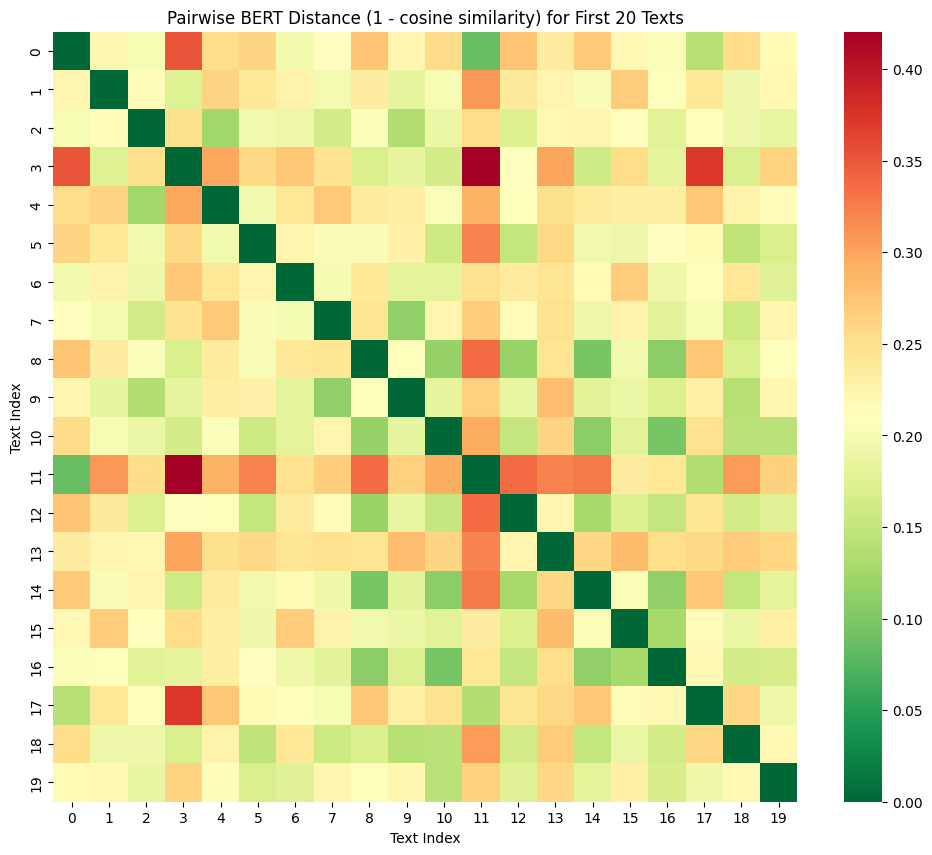

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(
    dist_matrix,
    cmap="RdYlGn_r",     # 🔥 red → yellow → green (green = good match)
    annot=False
)
plt.title("Pairwise BERT Distance (1 - cosine similarity) for First 20 Texts")
plt.xlabel("Text Index")
plt.ylabel("Text Index")
plt.show()


Combined labels: ['p005-gopro_009', 'p013-fastfood-sandwich_080', 'p025-firstaid_017', 'p017-baking_027', 'p005-instrument-makeup-dog-packing-massage-firstaid-cleaning-tool_198']


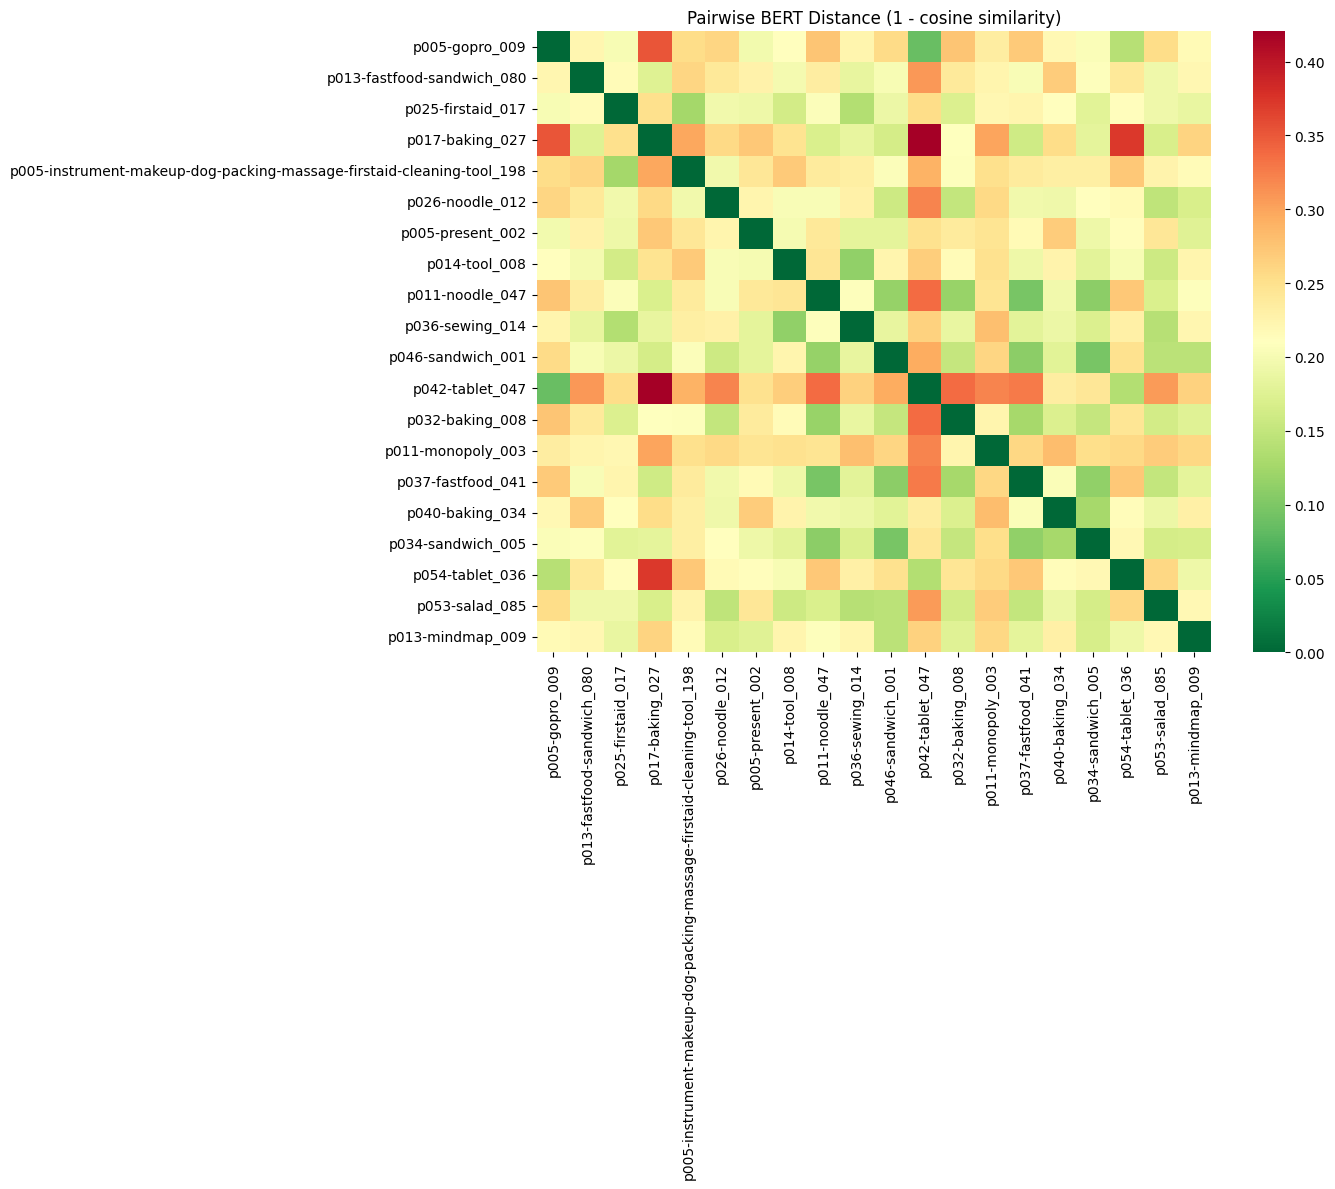

In [15]:
labels = [entry["scene"] for entry in file_list]
sequences = [entry["sequence"] for entry in file_list]
combined_labels = [f"{scene}_{seq}" for scene, seq in zip(labels, sequences)]

print("Combined labels:", combined_labels[:5])

plt.figure(figsize=(14, 12))
sns.heatmap(
    dist_matrix,
    cmap="RdYlGn_r",     # green = close, red = far
    xticklabels=combined_labels,
    yticklabels=combined_labels,
    annot=False
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Pairwise BERT Distance (1 - cosine similarity)")
plt.tight_layout()
plt.show()


In [22]:
import numpy as np
import json
from pathlib import Path

# Save directory = current directory
SAVE_DIR = Path(".")   # or Path.cwd()

# Save matrix as .npy
np.save(SAVE_DIR / "word_space_dist_matrix.npy", dist_matrix)

# Save labels as .json
with open(SAVE_DIR / "word_space_labels.json", "w") as f:
    json.dump(combined_labels, f, indent=4)

print("Saved:")
print(" - word_space_dist_matrix.npy")
print(" - word_space_labels.json")


Saved:
 - word_space_dist_matrix.npy
 - word_space_labels.json


# 🎨 Cluster and Project Sentence Embeddings
This cell works with the BERT embeddings of our 20 sentences, where each sentence is represented internally as a **768-dimensional semantic vector**.  
We cannot visualize 768 dimensions directly, so we do two things:

1. **KMeans clustering (in 768-dim space)**  
   This groups sentences based on their full high-dimensional BERT meaning.  
   The labels reflect true semantic structure in 768 dimensions.

2. **PCA reduction to 2D (for visualization only)**  
   PCA compresses the 768-dim vectors down to 2 axes so we can plot them.  
   Because we are squeezing 768 dimensions into just 2, some points from different clusters may appear close together or visually overlap even if they are well-separated in the full space.

In other words, the colors (clusters) are determined in full semantic space,  
while the positions on the plot are a simplified 2D projection.


In [16]:
# sentences = first 20 texts from before
embeddings = []

for text in sentences:
    emb = bert_embedding(bert_model, tokenizer, text, device)
    embeddings.append(emb)

embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)


# ---- CLUSTERING ----
from sklearn.cluster import KMeans

k = 6   # number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(embeddings)

print("Cluster labels:", labels)


# ---- PCA ----
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points_2d = pca.fit_transform(embeddings)

print("2D PCA shape:", points_2d.shape)
print("2D PCA points:\n", points_2d)


Embeddings shape: (20, 768)
Cluster labels: [2 4 5 1 5 3 2 0 1 0 1 2 3 4 1 3 1 2 1 3]
2D PCA shape: (20, 2)
2D PCA points:
 [[-3.1596837   0.31930205]
 [ 0.3274089   2.293448  ]
 [-0.42369407  0.26819846]
 [ 3.012895    1.7757064 ]
 [-0.22303219 -1.1634192 ]
 [ 0.67326355 -1.5543269 ]
 [-0.8123358   0.6502916 ]
 [-0.35488757  2.043762  ]
 [ 1.8843678  -1.0968992 ]
 [ 0.27549797  2.019875  ]
 [ 1.4951118  -1.0345556 ]
 [-4.4673905  -0.265243  ]
 [ 1.5022875  -1.4006023 ]
 [-0.47309506  0.4191012 ]
 [ 1.8777587  -0.35450584]
 [-0.16793075 -1.4155375 ]
 [ 0.67308724 -0.65272224]
 [-2.7998974  -0.36019573]
 [ 1.3784966   0.6189953 ]
 [-0.21822798 -1.1106738 ]]


# 📍 Visualize Clusters in 2D (PCA Projection)
This cell plots the 20 sentence embeddings in 2D after PCA reduction.  
Each point represents one instruction, colored by its cluster, with its index shown for reference.


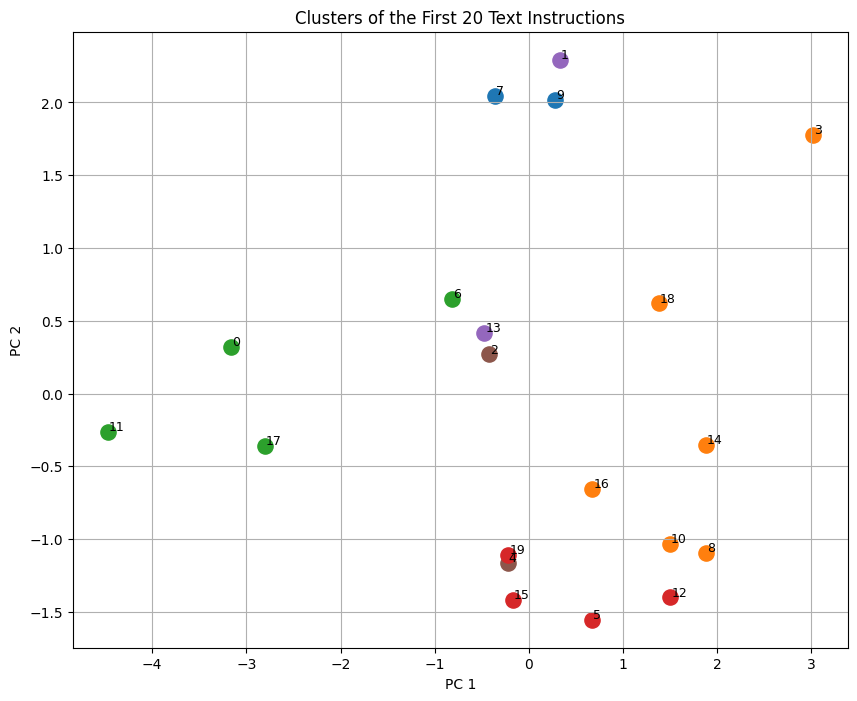

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i, (x, y) in enumerate(points_2d):
    plt.scatter(x, y, c=f"C{labels[i]}", s=120)
    plt.text(x + 0.01, y + 0.01, str(i), fontsize=9)

plt.title("Clusters of the First 20 Text Instructions")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.show()


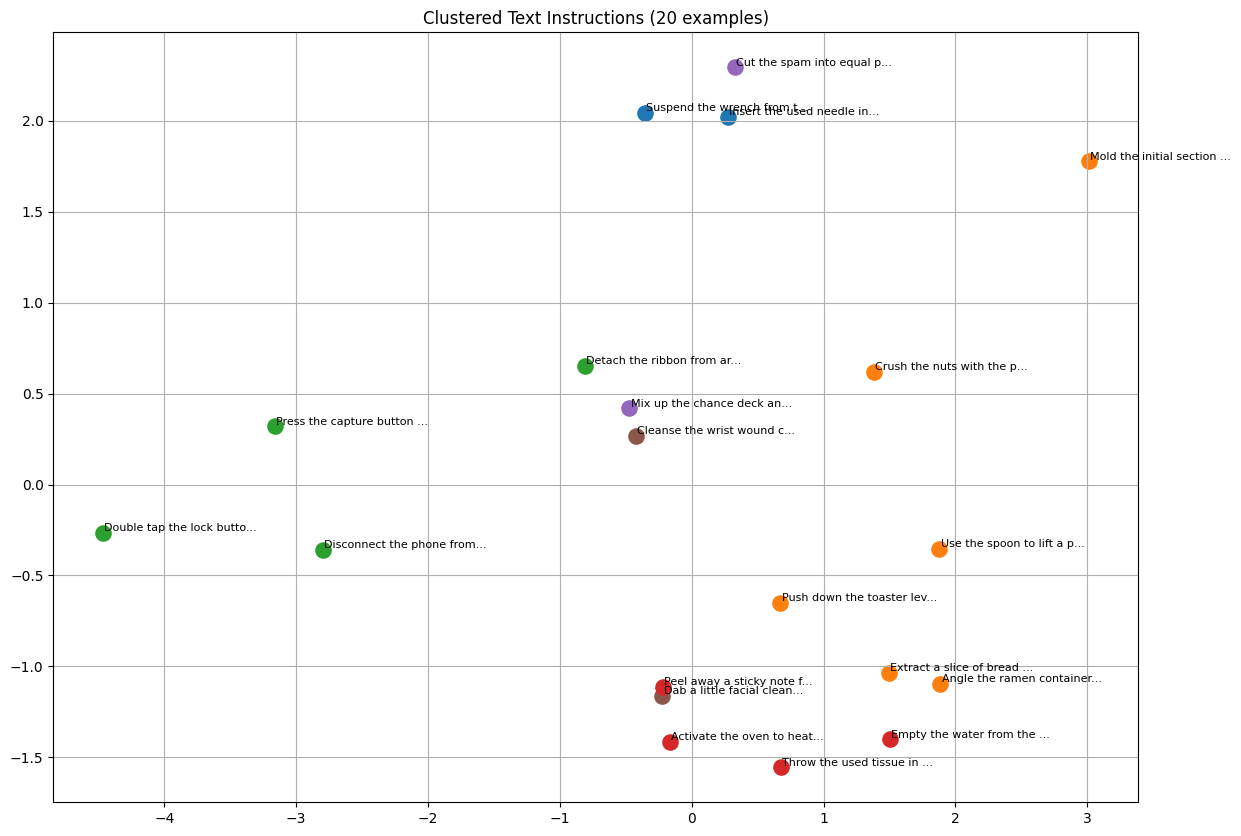

In [18]:
short = [s[:25] + "..." for s in sentences]

plt.figure(figsize=(14, 10))
for i, (x, y) in enumerate(points_2d):
    plt.scatter(x, y, c=f"C{labels[i]}", s=120)
    plt.text(x + 0.01, y + 0.01, short[i], fontsize=8)

plt.title("Clustered Text Instructions (20 examples)")
plt.grid(True)
plt.show()


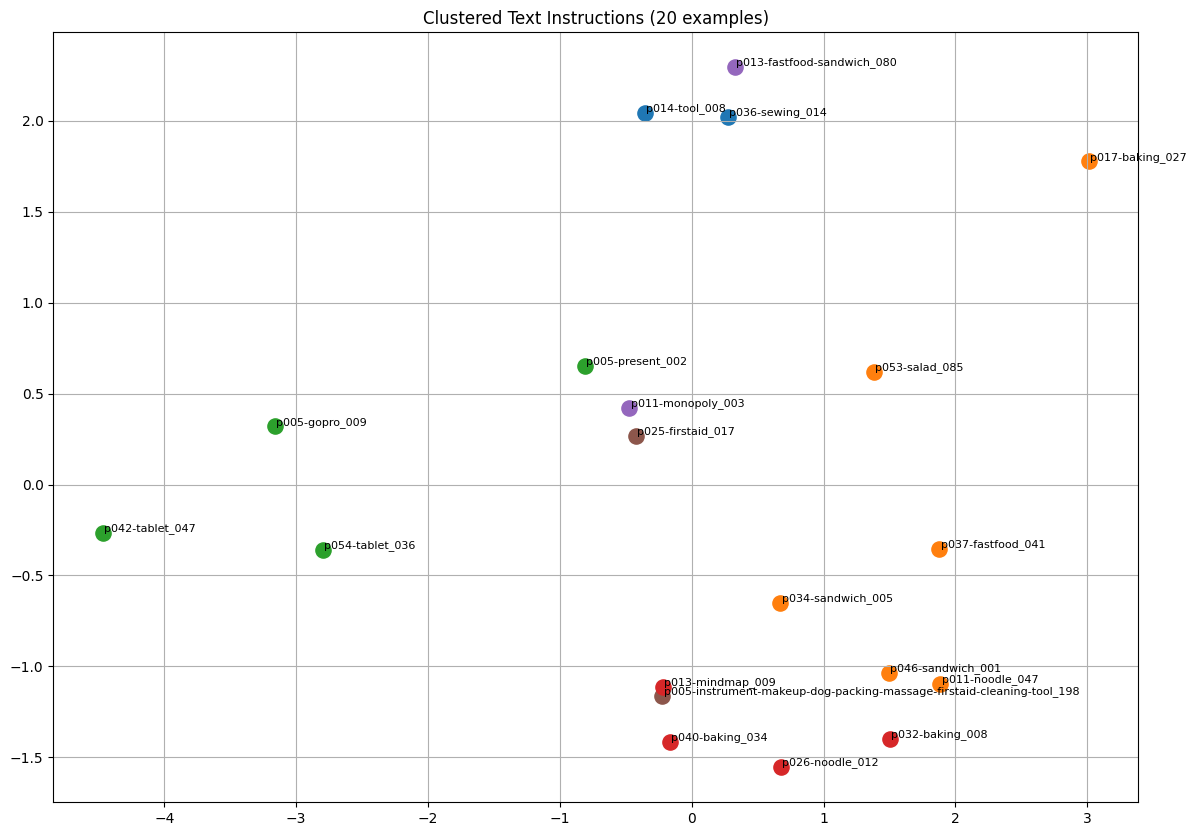

In [19]:
plt.figure(figsize=(14, 10))
scenes = [entry["scene"] for entry in file_list]
for i, (x, y) in enumerate(points_2d):
    # color stays EXACTLY the same:
    plt.scatter(x, y, c=f"C{labels[i]}", s=120)

    # 🔥 New label: scene_sequence
    node_id = f"{scenes[i]}_{sequences[i]}"
    plt.text(x + 0.01, y + 0.01, node_id, fontsize=8)

plt.title("Clustered Text Instructions (20 examples)")
plt.grid(True)
plt.show()


In [20]:
def get_repo_root():
    # --- CASE 1: Running inside a notebook ---
    if 'ipykernel' in sys.modules:
        # notebook file is usually inside <root>/scripts/... or <root>/analysis/...
        # so take the notebook cwd and go UP until we find the repo
        cwd = Path().resolve()
        # We assume the notebook is in <root>/scripts or <root>/analysis>
        # → repo root = parent folder
        return cwd.parents[0]

    # --- CASE 2: Running as a .py file ---
    return Path(__file__).resolve().parents[1]

REPO_ROOT = get_repo_root()
print("Detected REPO_ROOT =", REPO_ROOT)

Detected REPO_ROOT = D:\repos\refactored_MDM


In [21]:
OUT_DIR = Path(REPO_ROOT) / "semantic_spaces" / "saved_matrices"
OUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUT_DIR / "word_space_matrix.npy", word_matrix)
print("Saved word space matrix →", OUT_DIR / "word_space_matrix.npy")

NameError: name 'word_matrix' is not defined